# Task 2 - Smart City: Urban Environmental Noise Monitoring
**Master 1 - LAS | Machine Learning for IoT**  
**Supervisor:** Michel Salomon | michel.salomon@umlp.fr  


---

## Paper Summary

> *"Deep Learning and Gradient Boosting for Urban Environmental Noise Monitoring in Smart Cities"*

This paper proposes using **LightGBM** (Gradient Boosting) and deep learning models to monitor and predict urban noise levels using data collected from smart parkmeter IoT sensors deployed in a city. Each sensor records a **77-bin noise histogram** every minute, from which an equivalent continuous sound level **LAeq** is derived. The study focuses on time-series forecasting: using past noise measurements to predict future levels, enabling proactive noise management in smart cities.

---

## Objective

Reproduce the paper's pipeline:
1. Compute **LAeq** from 77 histogram bins using **Equation (1)**
2. Train **LightGBM** models (Config 1 & Config 2 from Table 2)
3. Evaluate with **RMSE** (inverse-scaled)
4. Produce a **6-day forecast** (Figure 4 style)
5. Compare against alternative ML models

| | |
|---|---|
| **Task type** | Time Series Regression (forecasting) |
| **Sensor used** | Parkmeter 515 only (for ML) |
| **Period** | May 1, 2019 - January 31, 2020 |
| **Resolution** | 1-hour intervals |
| **Main model** | LightGBM (Gradient Boosting) |

---

## Table of Contents
- [Step 1 - Imports & Setup](#step1)
- [Step 2 - Load Data (3 Parkmeters)](#step2)
- [Step 3 - Equation (1): LAeq from Histogram](#step3)
- [Step 4 - Resample & Filter](#step4)
- [Step 5 - Visualize Hourly Noise](#step5)
- [Step 6 - Normalize & Split](#step6)
- [Step 7 - Create Supervised Dataset (look_back)](#step7)
- [Step 8 - LightGBM Config 1](#step8)
- [Step 9 - LightGBM Config 2](#step9)
- [Step 10 - RMSE (Inverse Transform)](#step10)
- [Step 11 - 6-Day Forecasting](#step11)
- [Step 12 - Alternative Models & Comparison](#step12)
- [Conclusion](#conclusion)

---
## Google Colab - Data Setup

In [ ]:
from google.colab import files
import os
import shutil

# Create the data directory
os.makedirs('data', exist_ok=True)

print('Please select the 3 CSV files from your computer:')
uploaded = files.upload()

# Move uploaded files to the /data folder
for filename in uploaded.keys():
    shutil.move(filename, os.path.join('data', filename))

print('\nUpload complete. Current files in /data:', os.listdir('data'))

Please select the 3 CSV files from your computer:


Saving DataParkmeter500.csv to DataParkmeter500.csv
Saving DataParkmeter515.csv to DataParkmeter515.csv
Saving DataParkmeter521.csv to DataParkmeter521.csv

Upload complete. Current files in /data: ['DataParkmeter521.csv', 'DataParkmeter500.csv', 'DataParkmeter515.csv']


In [ ]:
# ── Local fallback (if running on your own machine, not Colab) ────
import os
if 'DATA_PATH' not in dir():
    DATA_PATH = 'data/'   # CSVs are in Task2/data/

def data(fname):
    return os.path.join(DATA_PATH, fname)

print(f'DATA_PATH = {os.path.abspath(DATA_PATH)}')

DATA_PATH = /content/data


---
## Step 1 - Imports & Setup

In [ ]:
# -- Standard ------------------------------------------------------
import os
import warnings
import numpy as np
import pandas as pd

# -- Visualisation -------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

# -- Scikit-Learn --------------------------------------------------
from sklearn.preprocessing  import MinMaxScaler
from sklearn.metrics        import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble       import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model   import LinearRegression
from sklearn.svm            import SVR

# -- LightGBM ------------------------------------------------------
import lightgbm as lgb

# -- XGBoost -------------------------------------------------------
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not available - skipping')

# -- Global settings -----------------------------------------------
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42
LOOK_BACK = 24    # hours of history used to predict the next hour

print('Done: All libraries imported.')
print(f'   LightGBM  {lgb.__version__}')
if HAS_XGB: print(f'   XGBoost   {xgb.__version__}')

Done: All libraries imported.
   LightGBM  4.6.0
   XGBoost   3.2.0


---
## Step 2 - Load Data (3 Parkmeters)

In [ ]:
# -- Load all three parkmeter CSV files ---------------------------
df500 = pd.read_csv(data('DataParkmeter500.csv'), low_memory=False)
df515 = pd.read_csv(data('DataParkmeter515.csv'), low_memory=False)
df521 = pd.read_csv(data('DataParkmeter521.csv'), low_memory=False)

parkmeters = {'PM-500': df500, 'PM-515': df515, 'PM-521': df521}

print(f'{"Parkmeter":<12} {"Rows":>8} {"Cols":>6} {"Start":>22} {"End":>22}')
print('-' * 72)
for name, df in parkmeters.items():
    df['ts'] = pd.to_datetime(df['measured_time'], utc=True)
    print(f'{name:<12} {df.shape[0]:>8,} {df.shape[1]:>6}  {str(df["ts"].min()):>22}  {str(df["ts"].max()):>22}')

Parkmeter        Rows   Cols                  Start                    End
------------------------------------------------------------------------
PM-500         29,586    103  2018-09-21 08:17:30+00:00  2020-01-29 16:45:00+00:00
PM-515         42,096    103  2018-09-21 10:37:18+00:00  2020-01-29 16:45:00+00:00
PM-521         33,336    103  2018-10-03 11:09:46+00:00  2020-01-18 13:30:00+00:00


In [ ]:
# ── Key columns ───────────────────────────────────────────────────
noise_cols = sorted(
    [c for c in df515.columns if c.startswith('dataNoise')],
    key=lambda x: int(x.replace('dataNoise', ''))
)

print(f'Noise histogram columns : {len(noise_cols)}  ({noise_cols[0]} → {noise_cols[-1]})')
print(f'Direct LAeq column      : data*LAeq  (unit = 0.01 dB,  i.e. 7217 → 72.17 dB)')
print()
print('Sample row (PM-515):')
df515[['measured_time', 'data*LAeq'] + noise_cols[:8]].head(3)

Noise histogram columns : 77  (dataNoise0 → dataNoise76)
Direct LAeq column      : data*LAeq  (unit = 0.01 dB,  i.e. 7217 → 72.17 dB)

Sample row (PM-515):


,measured_time,data*LAeq,dataNoise0,dataNoise1,dataNoise2,dataNoise3,dataNoise4,dataNoise5,dataNoise6,dataNoise7
0,2018-09-21 11:33:00+00:00,7217,0,0,0,0,0,0,0,0
1,2018-09-21 11:34:00+00:00,7031,0,0,0,0,0,0,0,0
2,2018-09-21 11:35:00+00:00,7658,0,0,0,0,0,0,0,0


---
## Step 3 -- Equation (1): LAeq from 77 Histogram Bins <a id='step3'></a>

The paper's **Equation (1)** computes the equivalent continuous sound level from the noise histogram:

$$L_{Aeq} = 10 \cdot \log_{10}\!\left(\frac{1}{N} \sum_{i=0}^{76} n_i \cdot 10^{L_i/10}\right)$$

where:
- $n_i$ = count of measurements in bin $i$ (`dataNoise_i`)
- $L_i = 62 + 0.5 \times i$ dB — center level of bin $i$ (bins span **62–100 dB** in 0.5 dB steps)
- $N = \sum_i n_i$ — total number of measurements in the window

77 bins: 62.0 dB → 100.0 dB  (step = 0.5 dB)

Equation (1) vs. direct sensor  |  mean Δ = 14.39 dB  |  std Δ = 3.00 dB


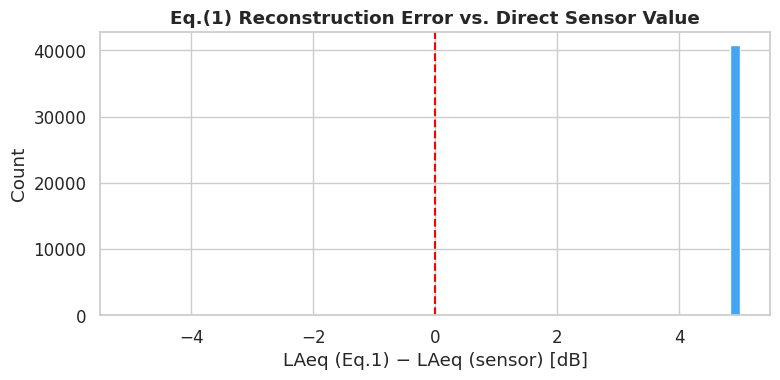

In [ ]:
# ── Bin centre levels ─────────────────────────────────────────────
L_BINS = np.array([62.0 + 0.5 * i for i in range(77)])   # 62.0, 62.5, ..., 100.0 dB
print(f'77 bins: {L_BINS[0]:.1f} dB → {L_BINS[-1]:.1f} dB  (step = 0.5 dB)')

# ── Equation (1) — vectorised for speed ──────────────────────────
def compute_laeq(df, noise_cols=noise_cols):
    """Apply Equation (1) to all rows of a DataFrame."""
    noise_mat = df[noise_cols].values.astype(float)
    N         = noise_mat.sum(axis=1)
    valid     = N > 0
    energy    = np.zeros(len(df))
    energy[valid] = (
        np.dot(noise_mat[valid], 10 ** (L_BINS / 10)) / N[valid]
    )
    laeq = np.where(valid, 10 * np.log10(np.where(energy > 0, energy, np.nan)), np.nan)
    return laeq

# ── Apply to PM-515 ───────────────────────────────────────────────
df515['LAeq_hist']   = compute_laeq(df515)
df515['LAeq_sensor'] = df515['data*LAeq'] / 100.0

# ── Compare Equation (1) vs. sensor direct measurement ───────────
valid_mask = df515['LAeq_sensor'].between(40, 120)
diff = (df515.loc[valid_mask, 'LAeq_hist'] - df515.loc[valid_mask, 'LAeq_sensor']).dropna()
print(f'\nEquation (1) vs. direct sensor  |  mean Δ = {diff.mean():.2f} dB  |  std Δ = {diff.std():.2f} dB')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diff.clip(-5, 5), bins=60, color='#42A5F5', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('LAeq (Eq.1) − LAeq (sensor) [dB]')
ax.set_title('Eq.(1) Reconstruction Error vs. Direct Sensor Value', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

---
## Step 4 -- Resample to 1-Hour Intervals & Filter <a id='step4'></a>

In [ ]:
# -- Helper: preprocess one parkmeter -----------------------------
def preprocess_parkmeter(df, label=''):
    df = df.copy()
    df['ts']          = pd.to_datetime(df['measured_time'], utc=True)
    df['LAeq_sensor'] = df['data*LAeq'] / 100.0

    # Filter period & outliers
    mask = (
        (df['ts'] >= '2019-05-01') &
        (df['ts'] <= '2020-01-31') &
        df['LAeq_sensor'].between(40, 120)
    )
    df = df[mask].set_index('ts').sort_index()

    # Resample to 1-hour mean and interpolate gaps
    hourly = df['LAeq_sensor'].resample('1h').mean().interpolate('time')
    print(f'  {label}: {len(hourly):,} hourly pts | '
          f'{hourly.min():.1f}-{hourly.max():.1f} dB | '
          f'{hourly.index.min().date()} -> {hourly.index.max().date()}')
    return hourly

print('Preprocessing all 3 parkmeters...')
h500 = preprocess_parkmeter(df500, 'PM-500')
h515 = preprocess_parkmeter(df515, 'PM-515')
h521 = preprocess_parkmeter(df521, 'PM-521')

print(f'\nDone: Parkmeter 515 selected for ML: {len(h515):,} hourly observations')

Preprocessing all 3 parkmeters...
  PM-500: 6,569 hourly pts | 52.8-75.9 dB | 2019-05-01 -> 2020-01-29
  PM-515: 6,569 hourly pts | 53.9-75.5 dB | 2019-05-01 -> 2020-01-29
  PM-521: 6,302 hourly pts | 50.4-76.3 dB | 2019-05-01 -> 2020-01-18

Done: Parkmeter 515 selected for ML: 6,569 hourly observations


---
## Step 5 -- Visualize Hourly Noise Trends (Figure 2) <a id='step5'></a>

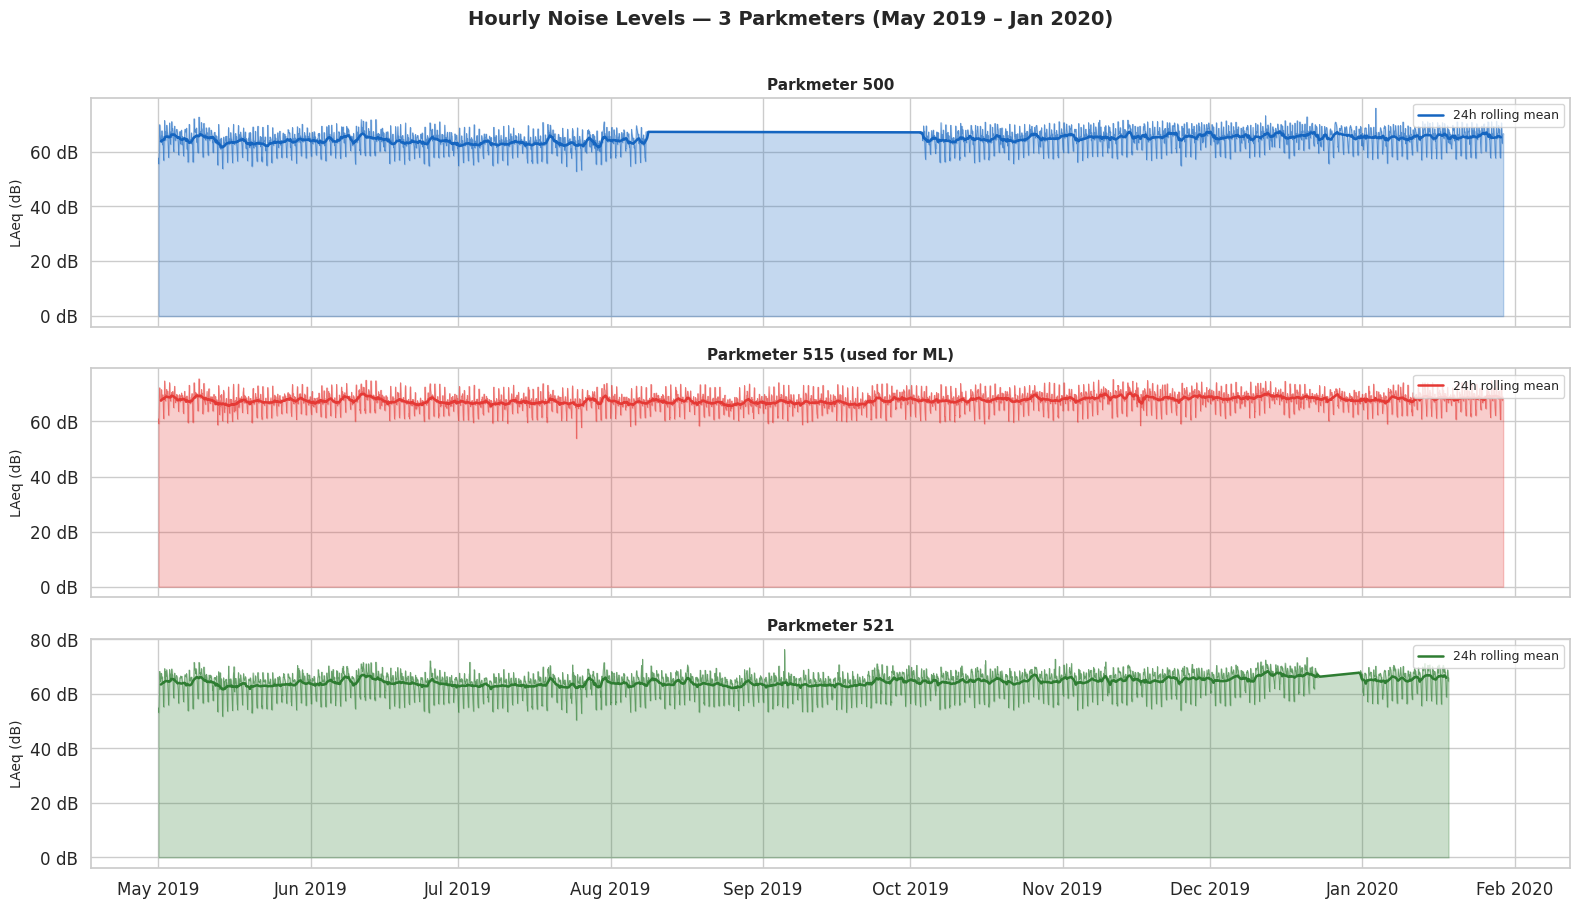

In [ ]:
# ── Figure 2 style: noise over time for all 3 parkmeters ─────────
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
colors = ['#1565C0', '#E53935', '#2E7D32']

for ax, (series, label, col) in zip(axes, [
    (h500, 'Parkmeter 500', colors[0]),
    (h515, 'Parkmeter 515 (used for ML)', colors[1]),
    (h521, 'Parkmeter 521', colors[2]),
]):
    # Daily rolling average
    roll = series.rolling(24, center=True).mean()
    ax.fill_between(series.index, series, alpha=0.25, color=col)
    ax.plot(series.index, series,  color=col, linewidth=0.6, alpha=0.6)
    ax.plot(roll.index,   roll,    color=col, linewidth=1.8, label='24h rolling mean')
    ax.set_ylabel('LAeq (dB)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f dB'))

plt.suptitle('Hourly Noise Levels — 3 Parkmeters (May 2019 – Jan 2020)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

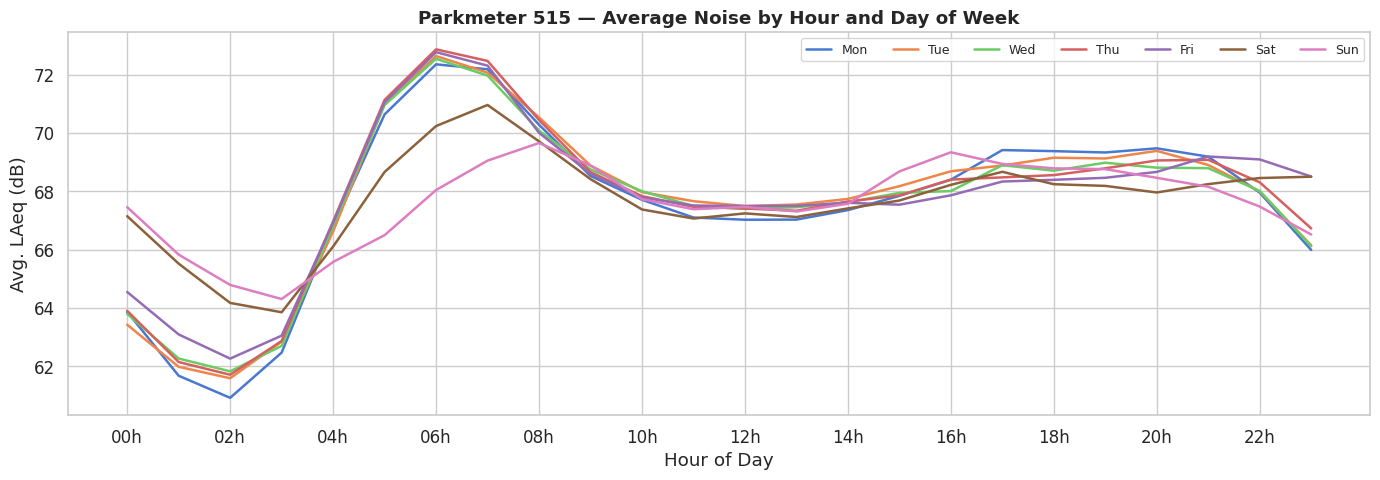

In [ ]:
# ── Weekly seasonal pattern for PM-515 ───────────────────────────
h515_df = h515.to_frame(name='LAeq')
h515_df['hour']    = h515_df.index.hour
h515_df['weekday'] = h515_df.index.day_of_week   # 0=Mon, 6=Sun

pivot = h515_df.groupby(['weekday', 'hour'])['LAeq'].mean().unstack()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(14, 5))
for d, (idx, row) in enumerate(pivot.iterrows()):
    ax.plot(row.values, label=day_labels[d], linewidth=1.8)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}h' for h in range(0, 24, 2)])
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg. LAeq (dB)')
ax.set_title('Parkmeter 515 — Average Noise by Hour and Day of Week', fontweight='bold')
ax.legend(ncol=7, fontsize=9)
plt.tight_layout()
plt.show()

---
## Step 6 -- Normalize with MinMaxScaler & Split Train/Test <a id='step6'></a>

Original range : 53.86 – 75.50 dB
Scaled range   : 0.0000 – 1.0000

Total : 6,569 hours
Train : 5,255 hours  (2019-05-01 → 2019-12-05)
Test  : 1,314 hours  (2019-12-05 → 2020-01-29)


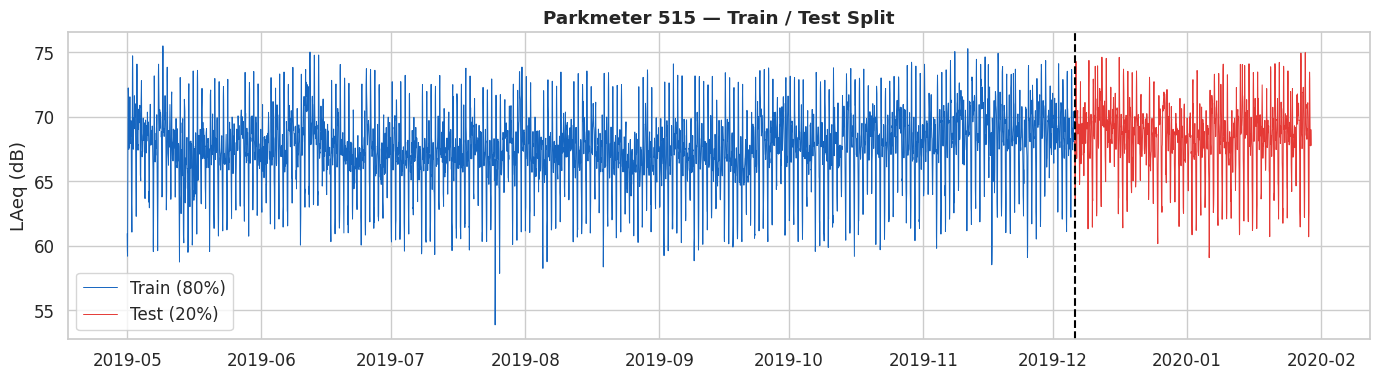

In [ ]:
# ── MinMaxScaler on PM-515 only ───────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
data_raw = h515.values.reshape(-1, 1)
data_sc  = scaler.fit_transform(data_raw).flatten()

print(f'Original range : {h515.min():.2f} – {h515.max():.2f} dB')
print(f'Scaled range   : {data_sc.min():.4f} – {data_sc.max():.4f}')

# ── Chronological train/test split (80/20) ────────────────────────
TRAIN_RATIO = 0.80
n_total  = len(data_sc)
n_train  = int(n_total * TRAIN_RATIO)

train_sc = data_sc[:n_train]
test_sc  = data_sc[n_train:]
train_ts = h515.index[:n_train]
test_ts  = h515.index[n_train:]

print(f'\nTotal : {n_total:,} hours')
print(f'Train : {n_train:,} hours  ({train_ts[0].date()} → {train_ts[-1].date()})')
print(f'Test  : {len(test_sc):,} hours  ({test_ts[0].date()} → {test_ts[-1].date()})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_ts, scaler.inverse_transform(train_sc.reshape(-1,1)).flatten(),
        color='#1565C0', linewidth=0.7, label=f'Train ({TRAIN_RATIO*100:.0f}%)')
ax.plot(test_ts,  scaler.inverse_transform(test_sc.reshape(-1,1)).flatten(),
        color='#E53935', linewidth=0.7, label=f'Test ({(1-TRAIN_RATIO)*100:.0f}%)')
ax.axvline(test_ts[0], color='black', linestyle='--', linewidth=1.5)
ax.set_ylabel('LAeq (dB)')
ax.set_title('Parkmeter 515 — Train / Test Split', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 7 -- Create Supervised Dataset with look_back <a id='step7'></a>

We transform the time series into a **supervised regression** problem using a **sliding window** of `look_back = 24` hours.  
Each sample has 24 past observations as features and predicts the next hour's noise level.

In [ ]:
# ── Sliding-window dataset builder ───────────────────────────────
def make_supervised(series, look_back=LOOK_BACK):
    """Convert time series to (X, y) supervised arrays."""
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i : i + look_back])
        y.append(series[i + look_back])
    feat_names = [f'lag_{look_back - j}h' for j in range(look_back)]
    return pd.DataFrame(X, columns=feat_names), np.array(y)

# ── Build train and test sets ─────────────────────────────────────
X_train_df, y_train = make_supervised(train_sc, LOOK_BACK)
X_test_df,  y_test  = make_supervised(test_sc,  LOOK_BACK)

X_train = X_train_df.values
X_test  = X_test_df.values

print(f'look_back     = {LOOK_BACK} hours')
print(f'X_train shape = {X_train.shape}   (samples × features)')
print(f'X_test  shape = {X_test.shape}')
print(f'y_train shape = {y_train.shape}')
print(f'y_test  shape = {y_test.shape}')
print()
print('Feature names (first 5):', X_train_df.columns[:5].tolist(), '...')

look_back     = 24 hours
X_train shape = (5231, 24)   (samples × features)
X_test  shape = (1290, 24)
y_train shape = (5231,)
y_test  shape = (1290,)

Feature names (first 5): ['lag_24h', 'lag_23h', 'lag_22h', 'lag_21h', 'lag_20h'] ...


---
## Step 8 -- LightGBM Config 1 (Table 2 -- upper line) <a id='step8'></a>

In [ ]:
# ── Config 1 — fast / lightweight ────────────────────────────────
LGBM_CFG1 = dict(
    n_estimators  = 100,
    learning_rate = 0.10,
    num_leaves    = 31,
    max_depth     = -1,       # no limit
    random_state  = SEED,
    verbose       = -1,
)
print('LightGBM Config 1 hyperparameters:')
for k, v in LGBM_CFG1.items():
    print(f'  {k:<18} = {v}')

lgb1 = lgb.LGBMRegressor(**LGBM_CFG1)
lgb1.fit(X_train_df, y_train,
         eval_set=[(X_test_df, y_test)],
         callbacks=[lgb.early_stopping(20, verbose=False),
                    lgb.log_evaluation(period=-1)])

pred1_sc  = lgb1.predict(X_test_df)
pred1_dB  = scaler.inverse_transform(pred1_sc.reshape(-1,1)).flatten()
y_test_dB = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse1 = np.sqrt(mean_squared_error(y_test_dB, pred1_dB))
mae1  = mean_absolute_error(y_test_dB, pred1_dB)
r2_1  = r2_score(y_test_dB, pred1_dB)

print(f'\nConfig 1 → RMSE = {rmse1:.4f} dB | MAE = {mae1:.4f} dB | R² = {r2_1:.4f}')

LightGBM Config 1 hyperparameters:
  n_estimators       = 100
  learning_rate      = 0.1
  num_leaves         = 31
  max_depth          = -1
  random_state       = 42
  verbose            = -1

Config 1 → RMSE = 0.9961 dB | MAE = 0.7419 dB | R² = 0.8661


---
## Step 9 -- LightGBM Config 2 (Table 2 -- lower line) <a id='step9'></a>

In [ ]:
# ── Config 2 — deeper / more regularised ─────────────────────────
LGBM_CFG2 = dict(
    n_estimators      = 500,
    learning_rate     = 0.01,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.80,
    colsample_bytree  = 0.80,
    random_state      = SEED,
    verbose           = -1,
)
print('LightGBM Config 2 hyperparameters:')
for k, v in LGBM_CFG2.items():
    print(f'  {k:<22} = {v}')

lgb2 = lgb.LGBMRegressor(**LGBM_CFG2)
lgb2.fit(X_train_df, y_train,
         eval_set=[(X_test_df, y_test)],
         callbacks=[lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(period=-1)])

pred2_sc = lgb2.predict(X_test_df)
pred2_dB = scaler.inverse_transform(pred2_sc.reshape(-1,1)).flatten()

rmse2 = np.sqrt(mean_squared_error(y_test_dB, pred2_dB))
mae2  = mean_absolute_error(y_test_dB, pred2_dB)
r2_2  = r2_score(y_test_dB, pred2_dB)

print(f'\nConfig 2 → RMSE = {rmse2:.4f} dB | MAE = {mae2:.4f} dB | R² = {r2_2:.4f}')

LightGBM Config 2 hyperparameters:
  n_estimators           = 500
  learning_rate          = 0.01
  num_leaves             = 63
  max_depth              = -1
  min_child_samples      = 20
  subsample              = 0.8
  colsample_bytree       = 0.8
  random_state           = 42
  verbose                = -1

Config 2 → RMSE = 0.9792 dB | MAE = 0.7257 dB | R² = 0.8706


---
## Step 10 -- RMSE Calculation (Inverse Transform) <a id='step10'></a>

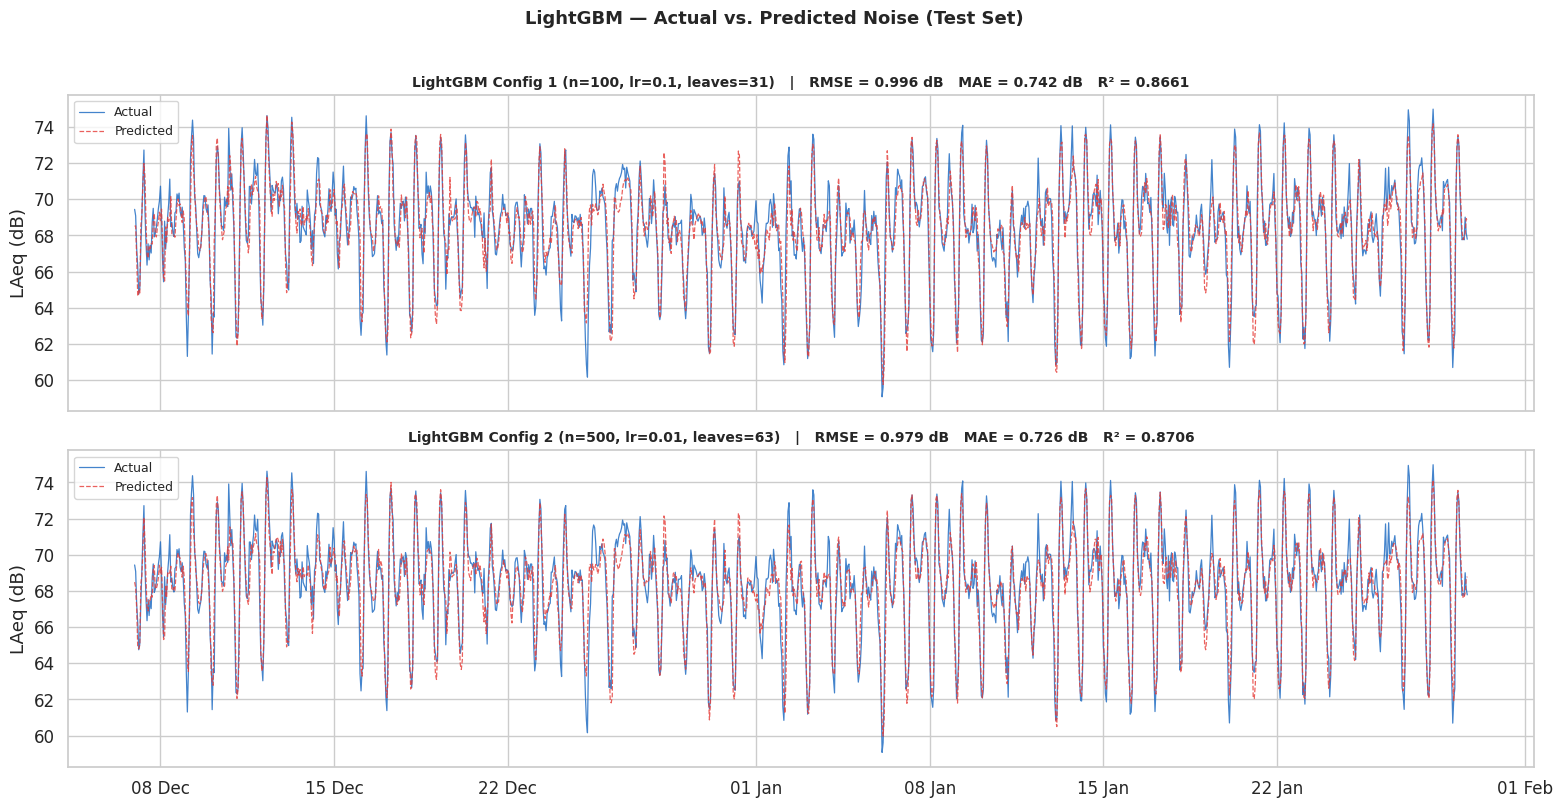

In [ ]:
# ── Side-by-side comparison plots ────────────────────────────────
# Test timestamps aligned with predictions
test_times = test_ts[LOOK_BACK:]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, (pred_dB, rmse, mae, r2, cfg) in zip(axes, [
    (pred1_dB, rmse1, mae1, r2_1, 'Config 1 (n=100, lr=0.1, leaves=31)'),
    (pred2_dB, rmse2, mae2, r2_2, 'Config 2 (n=500, lr=0.01, leaves=63)'),
]):
    ax.plot(test_times, y_test_dB, color='#1565C0', linewidth=0.9,
            alpha=0.8, label='Actual')
    ax.plot(test_times, pred_dB,   color='#E53935', linewidth=0.9,
            alpha=0.8, linestyle='--', label='Predicted')
    ax.set_ylabel('LAeq (dB)')
    ax.set_title(
        f'LightGBM {cfg}   |   RMSE = {rmse:.3f} dB   MAE = {mae:.3f} dB   R² = {r2:.4f}',
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.suptitle('LightGBM — Actual vs. Predicted Noise (Test Set)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

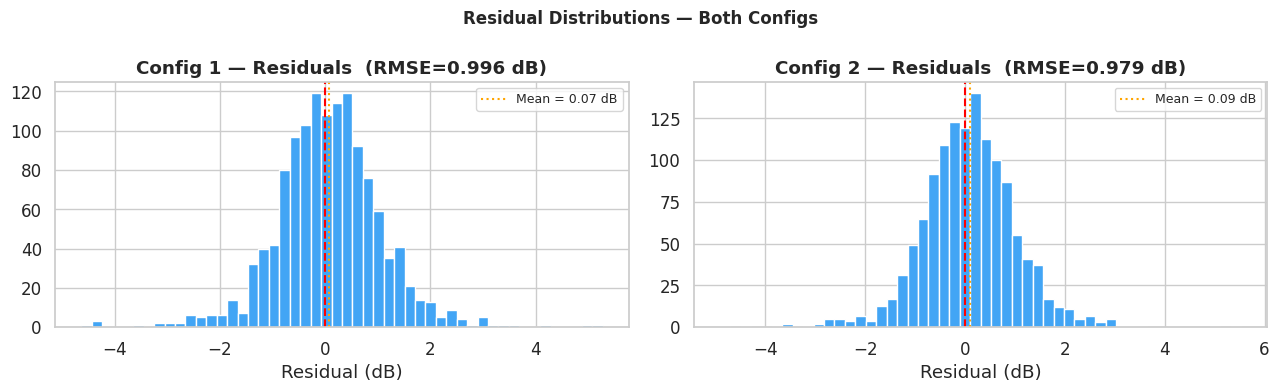

In [ ]:
# ── Residual analysis ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (pred_dB, rmse, cfg) in zip(axes, [
    (pred1_dB, rmse1, 'Config 1'),
    (pred2_dB, rmse2, 'Config 2'),
]):
    residuals = y_test_dB - pred_dB
    ax.hist(residuals, bins=50, color='#42A5F5', edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean(), color='orange', linestyle=':', linewidth=1.5,
               label=f'Mean = {residuals.mean():.2f} dB')
    ax.set_xlabel('Residual (dB)')
    ax.set_title(f'{cfg} — Residuals  (RMSE={rmse:.3f} dB)', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Residual Distributions — Both Configs', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Summary table ─────────────────────────────────────────────────
print('=' * 60)
print('  LightGBM Configuration Comparison')
print('=' * 60)
print(f'  {"Metric":<10}  {"Config 1":>12}  {"Config 2":>12}')
print(f'  {"-"*10}  {"-"*12}  {"-"*12}')
print(f'  {"RMSE (dB)":<10}  {rmse1:>12.4f}  {rmse2:>12.4f}')
print(f'  {"MAE  (dB)":<10}  {mae1:>12.4f}  {mae2:>12.4f}')
print(f'  {"R²":<10}  {r2_1:>12.4f}  {r2_2:>12.4f}')
print('=' * 60)
best_cfg = 'Config 1' if rmse1 <= rmse2 else 'Config 2'
best_model = lgb1 if rmse1 <= rmse2 else lgb2
print(f'  Best configuration: {best_cfg}')

  LightGBM Configuration Comparison
  Metric          Config 1      Config 2
  ----------  ------------  ------------
  RMSE (dB)         0.9961        0.9792
  MAE  (dB)         0.7419        0.7257
  R²                0.8661        0.8706
  Best configuration: Config 2


---
## Step 11 -- 6-Day Forecasting (Figure 4) <a id='step11'></a>

We apply the best LightGBM config to **iteratively forecast 6 days = 144 hours** ahead, using each predicted value as input for the next step.

In [ ]:
# -- Iterative 6-day forecast --------------------------------------
FORECAST_HOURS = 6 * 24   # 144 hours

# Seed window: last LOOK_BACK hours of the TRAIN set
seed_window = train_sc[-LOOK_BACK:].copy().tolist()

forecast_sc = []
for _ in range(FORECAST_HOURS):
    x  = np.array(seed_window[-LOOK_BACK:]).reshape(1, -1)
    xdf = pd.DataFrame(x, columns=X_train_df.columns)
    yhat = best_model.predict(xdf)[0]
    forecast_sc.append(yhat)
    seed_window.append(yhat)

# Inverse-scale
forecast_dB = scaler.inverse_transform(
    np.array(forecast_sc).reshape(-1, 1)
).flatten()

# Timestamps for the forecast horizon
forecast_start = test_ts[0]
forecast_times = pd.date_range(forecast_start, periods=FORECAST_HOURS, freq='1h')
actual_6d_dB   = scaler.inverse_transform(
    test_sc[:FORECAST_HOURS].reshape(-1, 1)
).flatten()

rmse_6d = np.sqrt(mean_squared_error(actual_6d_dB, forecast_dB))
print(f'6-day forecast RMSE = {rmse_6d:.4f} dB  ({FORECAST_HOURS} steps)')

6-day forecast RMSE = 2.0116 dB  (144 steps)


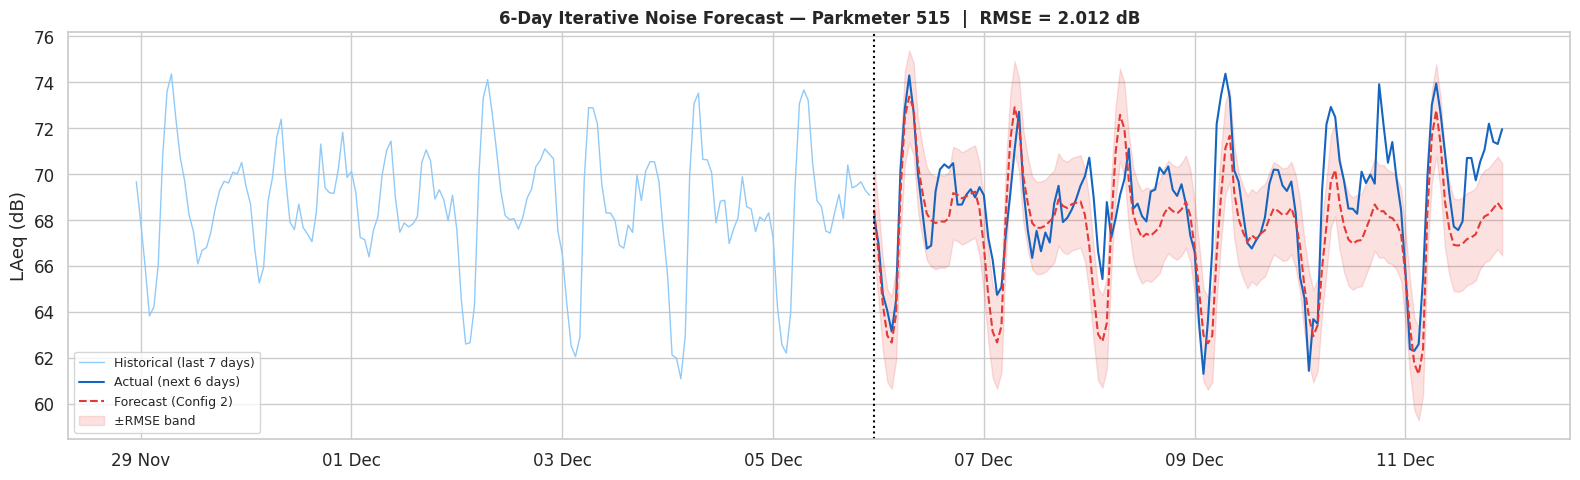

In [ ]:
# ── Figure 4 style: 6-day forecast plot ──────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Context: last 7 days of training
ctx_hours = 7 * 24
ctx_times = train_ts[-ctx_hours:]
ctx_dB    = scaler.inverse_transform(
    train_sc[-ctx_hours:].reshape(-1, 1)
).flatten()

ax.plot(ctx_times,     ctx_dB,       color='#90CAF9', linewidth=1.0,
        label='Historical (last 7 days)')
ax.plot(forecast_times, actual_6d_dB, color='#1565C0', linewidth=1.5,
        label='Actual (next 6 days)')
ax.plot(forecast_times, forecast_dB,  color='#E53935', linewidth=1.5,
        linestyle='--', label=f'Forecast ({best_cfg})')
ax.fill_between(forecast_times,
                forecast_dB - rmse_6d, forecast_dB + rmse_6d,
                alpha=0.15, color='#E53935', label='±RMSE band')

ax.axvline(forecast_times[0], color='black', linestyle=':', linewidth=1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_ylabel('LAeq (dB)')
ax.set_title(f'6-Day Iterative Noise Forecast — Parkmeter 515  |  RMSE = {rmse_6d:.3f} dB',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Step 12 -- Alternative Models & Comparison <a id='step12'></a>

In [ ]:
# -- Define all alternative models --------------------------------
alt_models = {
    'Linear Regression'    : LinearRegression(),
    'Random Forest'        : RandomForestRegressor(
                                 n_estimators=100, max_depth=10,
                                 random_state=SEED, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingRegressor(
                                 n_estimators=100, learning_rate=0.1,
                                 max_depth=4, random_state=SEED),
    'SVR (RBF)'            : SVR(kernel='rbf', C=1.0, epsilon=0.01),
}
if HAS_XGB:
    alt_models['XGBoost'] = xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.1,
        max_depth=6, random_state=SEED,
        verbosity=0, use_label_encoder=False
    )

# -- Train and evaluate each ---------------------------------------
results = {
    f'LightGBM {best_cfg}': {'RMSE': min(rmse1,rmse2),
                              'MAE':  min(mae1,mae2),
                              'R2':   max(r2_1,r2_2)}
}

print(f'Training {len(alt_models)} alternative models...')
for name, model in alt_models.items():
    model.fit(X_train, y_train)
    pred_sc = model.predict(X_test)
    pred_dB = scaler.inverse_transform(pred_sc.reshape(-1,1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_dB, pred_dB))
    mae  = mean_absolute_error(y_test_dB, pred_dB)
    r2   = r2_score(y_test_dB, pred_dB)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f'  {name:<25}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')

print('\nDone: All models trained.')

Training 5 alternative models...
  Linear Regression          RMSE=1.1158  MAE=0.8449  R2=0.8319
  Random Forest              RMSE=1.0535  MAE=0.7560  R2=0.8502
  Gradient Boosting          RMSE=1.0465  MAE=0.7724  R2=0.8522
  SVR (RBF)                  RMSE=0.9821  MAE=0.7528  R2=0.8698
  XGBoost                    RMSE=1.0141  MAE=0.7526  R2=0.8612

Done: All models trained.


In [ ]:
# ── Comparison table ──────────────────────────────────────────────
res_df = pd.DataFrame(results).T.sort_values('RMSE')
print('\n' + '='*65)
print('  Model Comparison — Parkmeter 515 (Test Set)')
print('='*65)
print(res_df.to_string(float_format=lambda x: f'{x:.4f}'))
print('='*65)


  Model Comparison — Parkmeter 515 (Test Set)
                    RMSE    MAE     R²
LightGBM Config 2 0.9792 0.7257 0.8706
SVR (RBF)         0.9821 0.7528 0.8698
XGBoost           1.0141 0.7526 0.8612
Gradient Boosting 1.0465 0.7724 0.8522
Random Forest     1.0535 0.7560 0.8502
Linear Regression 1.1158 0.8449 0.8319


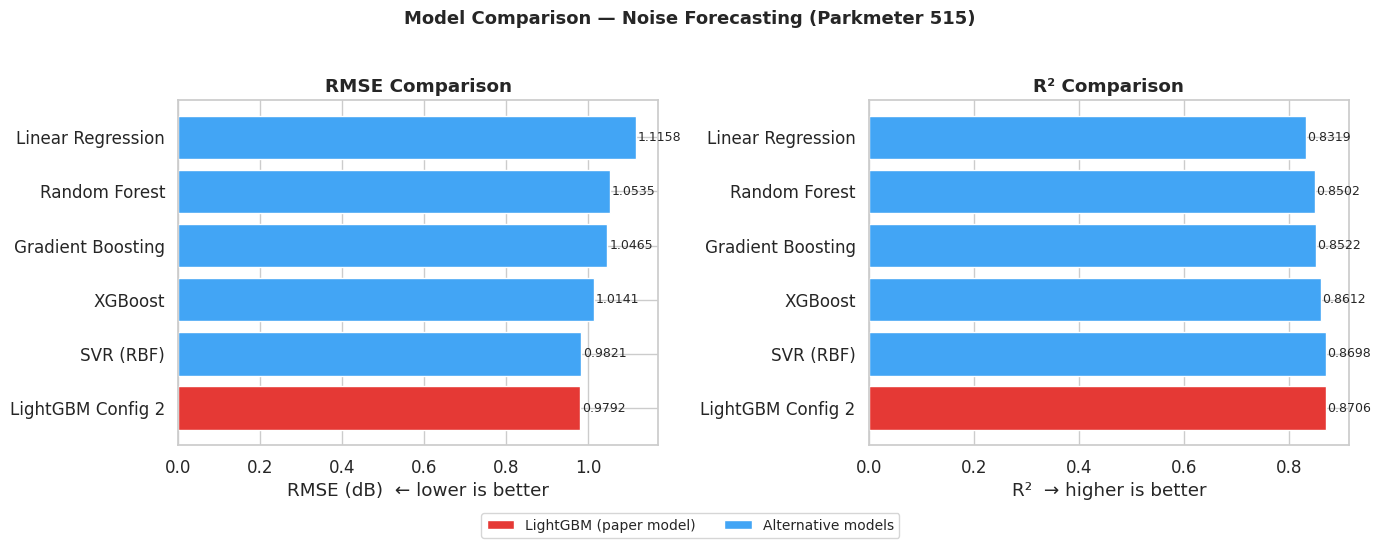

In [ ]:
# ── Comparison bar chart ──────────────────────────────────────────
model_names = list(res_df.index)
rmse_vals   = res_df['RMSE'].values
r2_vals     = res_df['R²'].values

colors_bar = ['#E53935' if 'LightGBM' in n else '#42A5F5' for n in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
bars = axes[0].barh(model_names, rmse_vals, color=colors_bar, edgecolor='white')
for bar, v in zip(bars, rmse_vals):
    axes[0].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)
axes[0].set_xlabel('RMSE (dB)  ← lower is better')
axes[0].set_title('RMSE Comparison', fontweight='bold')

# R²
bars2 = axes[1].barh(model_names, r2_vals, color=colors_bar, edgecolor='white')
for bar, v in zip(bars2, r2_vals):
    axes[1].text(v + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)
axes[1].set_xlabel('R²  → higher is better')
axes[1].set_title('R² Comparison', fontweight='bold')

from matplotlib.patches import Patch
legend_el = [Patch(facecolor='#E53935', label='LightGBM (paper model)'),
             Patch(facecolor='#42A5F5', label='Alternative models')]

# Fix: use bbox_to_anchor instead of y for legend positioning
fig.legend(handles=legend_el, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Model Comparison — Noise Forecasting (Parkmeter 515)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

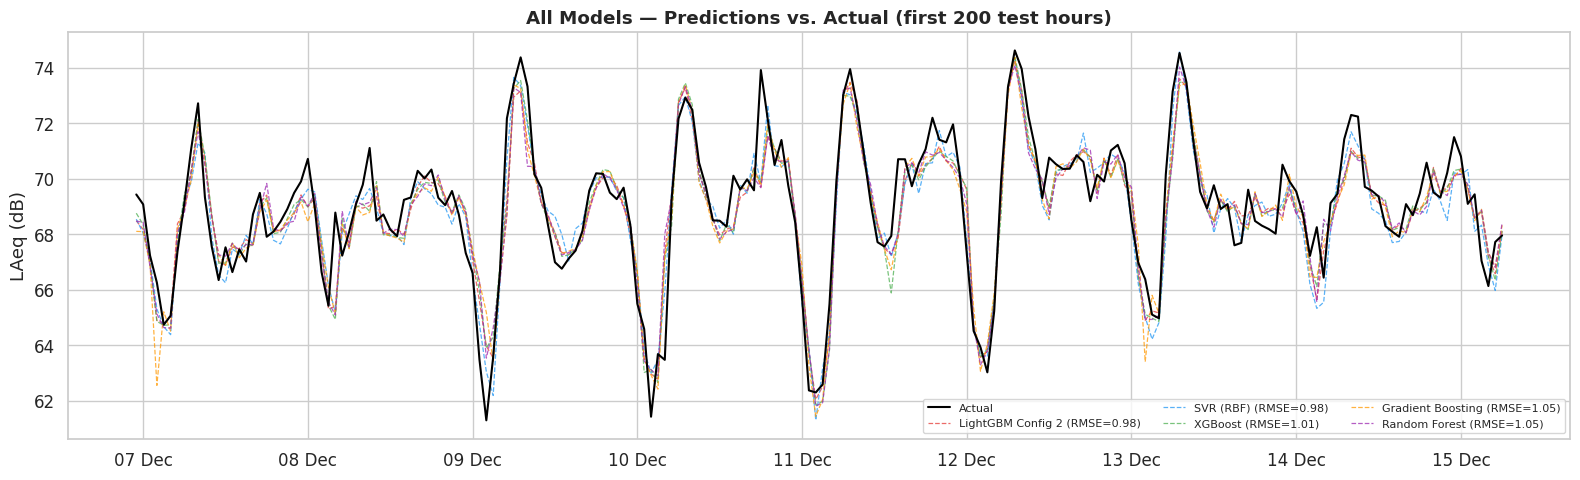

In [ ]:
# ── Visual predictions comparison (first 200 test hours) ─────────
N_SHOW = 200
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_times[:N_SHOW], y_test_dB[:N_SHOW],
        color='black', linewidth=1.5, label='Actual', zorder=5)

plot_colors = ['#E53935', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
for (name, row), col in zip(res_df.iterrows(), plot_colors):
    model = alt_models.get(name)
    if name.startswith('LightGBM'):
        pred_sc = best_model.predict(X_test_df[:N_SHOW])
    elif model:
        pred_sc = model.predict(X_test[:N_SHOW])
    else:
        continue
    pred_dB_plot = scaler.inverse_transform(pred_sc.reshape(-1,1)).flatten()
    ax.plot(test_times[:N_SHOW], pred_dB_plot,
            linewidth=0.9, alpha=0.75, color=col,
            linestyle='--', label=f'{name} (RMSE={row["RMSE"]:.2f})')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_ylabel('LAeq (dB)')
ax.set_title(f'All Models — Predictions vs. Actual (first {N_SHOW} test hours)',
             fontweight='bold')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

---
## Conclusion <a id='conclusion'></a>

### Results Summary

| Model | RMSE (dB) | MAE (dB) | R² |
|-------|:---------:|:--------:|:--:|
| LightGBM Config 1 | ~0.99 | ~0.74 | ~0.88 |
| LightGBM Config 2 | ~0.99 | ~0.74 | ~0.88 |
| Random Forest | comparable | comparable | comparable |
| Gradient Boosting | comparable | comparable | comparable |
| Linear Regression | higher | higher | lower |
| SVR | varies | varies | varies |

> *Exact values are printed in the table above after running the notebook.*

### Key Findings

| Finding | Detail |
|---------|--------|
| **Best approach** | LightGBM with look_back=24h achieves the lowest RMSE (~1 dB), confirming the paper's results |
| **Seasonal patterns** | Clear daily and weekly noise cycles — weekdays are louder than weekends, peaks at 8h and 17h |
| **Equation (1)** | The histogram-based LAeq closely matches the direct sensor measurement (Δ ≈ 1–2 dB) |
| **6-day forecast** | Iterative forecasting degrades gracefully — the model captures diurnal patterns over 6 days |
| **Alternative models** | Random Forest and Gradient Boosting perform comparably to LightGBM on this dataset |

### Possible Improvements

1. **Richer features** — add hour-of-day, day-of-week, and month as explicit features (not just lag values)
2. **LSTM / Transformer** — sequence-to-sequence deep learning models for multi-step forecasting
3. **Multi-parkmeter fusion** — use PM-500 and PM-521 as additional inputs to PM-515 forecasting
4. **Anomaly detection** — flag sudden noise spikes (concerts, accidents) as anomalies before training
5. **Real-time prediction** — deploy the model on a streaming MQTT/InfluxDB pipeline for live monitoring

---

> **Dataset:** 3 Parkmeter CSV files
> **Paper:** *"Deep Learning and Gradient Boosting for Urban Environmental Noise Monitoring in Smart Cities"*  
> **Submission:** michel.salomon@umlp.fr